In [1]:
#connect the library sqlite for SQL operation like create , connect and query
#No pip install required as it comes with python library
import sqlite3 as sql

In [2]:
#For work with table(rows and cols) in the database
import pandas as pd

In [3]:
#For vizualize the data like graph charts
import matplotlib.pyplot as plt

In [4]:
#Ignoring the small errors as a warning and show only the large error
import warnings
warnings.filterwarnings('ignore')

In [5]:
#To check the version of the pandas and sqlite
print(pd.__version__)
print(sql.version)

2.2.2
2.6.0


In [6]:
#mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#Read the csv file using pandas
df=pd.read_csv('student_performance.csv')

In [8]:
#for rows and cols
df.shape

(30, 13)

In [9]:
#for rows
df.shape[0]

30

In [10]:
#For cols
df.shape[1]

13

In [11]:
#for columns in the vertical
df.columns.tolist()

['student_id',
 'name',
 'age',
 'gender',
 'department',
 'semester',
 'math_score',
 'science_score',
 'english_score',
 'programming_score',
 'attendance_percentage',
 'city',
 'admission_year']

In [12]:
#For columns in the horizontal
print(df.columns.tolist())

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [13]:
#For print the 5 rows
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [14]:
#For print the last 5 days
df.tail()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
25,1026,Rekha Nair,20,Female,Electronics,2,72,77,73,63,82,Kochi,2023
26,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023
27,1028,Sunita Pillai,19,Female,Civil,2,60,65,68,39,73,Thiruvananthapuram,2023
28,1029,Nitin Jain,20,Male,Mechanical,2,75,76,70,50,84,Indore,2023
29,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023


In [15]:
#connect or create the database file
#File created in the colab file system
#If already exist it will open
#Otherwise it will create the new file
con=sql.connect('college.db')

In [16]:
#It is like a pen where we can write or do operation by sql commands in the database
cursor=con.cursor()

In [17]:
#Write the dataframe to the database as a table
df.to_sql(
    name='students', #name the table to create in the database
    con=con, #connection
    if_exists='replace', #If the table is already there then it will replace in the students table in the database
    index=False #Avoid converting the index of ros and the cols
)

30

In [18]:
#Execute the query using the cursor
#COUNT(*) used for the count the number of rows
cursor.execute("SELECT COUNT(*) FROM students");

In [19]:
#Store the result of the cursor and print first value
count =cursor.fetchone()[0]
print(count)

30


sample1

In [20]:
cursor.execute("SELECT SUM('math_score') as SUM FROM students")
table =cursor.fetchone()[0]
print(table)

0.0


sample2

In [21]:
cursor.execute("SELECT * FROM students")
table1=cursor.fetchall()
print(table1)

[(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023), (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023), (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023), (1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023), (1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023), (1006, 'Meera Joshi', 20, 'Female', 'Electronics', 2, 58, 66, 70, 52, 72, 'Pune', 2023), (1007, 'Kiran Kumar', 21, 'Male', 'Civil', 2, 73, 69, 65, 40, 85, 'Bangalore', 2023), (1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023), (1009, 'Rahul Mishra', 20, 'Male', 'Mechanical', 2, 62, 71, 58, 45, 68, 'Varanasi', 2023), (1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023), (1011, 'Vikram Iyer', 20, 'Male', 'Electronics', 2, 80, 75, 68, 72, 83, '

In [22]:
#pragma is the special sqlite command (not standard SQL)
#table_info shows the structure of the table like column and the datatype
cursor.execute("PRAGMA table_info(students)")
column_info=cursor.fetchall()
print(column_info)

[(0, 'student_id', 'INTEGER', 0, None, 0), (1, 'name', 'TEXT', 0, None, 0), (2, 'age', 'INTEGER', 0, None, 0), (3, 'gender', 'TEXT', 0, None, 0), (4, 'department', 'TEXT', 0, None, 0), (5, 'semester', 'INTEGER', 0, None, 0), (6, 'math_score', 'INTEGER', 0, None, 0), (7, 'science_score', 'INTEGER', 0, None, 0), (8, 'english_score', 'INTEGER', 0, None, 0), (9, 'programming_score', 'INTEGER', 0, None, 0), (10, 'attendance_percentage', 'INTEGER', 0, None, 0), (11, 'city', 'TEXT', 0, None, 0), (12, 'admission_year', 'INTEGER', 0, None, 0)]


In [23]:
#structured way to print the above data
# using the < and > for spacing
#using * for repeating
print("Structure of the students with datatype")
print(f"{'Column names':<25} {'Datatypes':<25}")
print("*"*40)
for col in column_info:
  print(f'{col[1]:<25} {col[2]:<25}')


Structure of the students with datatype
Column names              Datatypes                
****************************************
student_id                INTEGER                  
name                      TEXT                     
age                       INTEGER                  
gender                    TEXT                     
department                TEXT                     
semester                  INTEGER                  
math_score                INTEGER                  
science_score             INTEGER                  
english_score             INTEGER                  
programming_score         INTEGER                  
attendance_percentage     INTEGER                  
city                      TEXT                     
admission_year            INTEGER                  


# The Standard SQL Query Pattern


---
`SELECT col1,col2` ->which col to show

`FROM tableName` ->which table name to read

`WHERE codn` -> Filter the rows

`GROUP BY col`-> group rows

`HAVING codn` -> filter the groups

`ORDER BY col DES` -> sort the result

`LIMIT 10` -> max rows to return



Function which print the column and datatype in the structured way

In [24]:
#helper function to run sql queries
def run_query(sql,description=""):
  #----------------parameters-----------------------------
  #sql         -> str: the sql query string to execute
  #description -> str: A label to print the above results
  #----------------returns--------------------------------
  #Pandas dataframe contain the query results
  if description:
    print(f"\n{'='*80}")
    print(f"{description}")
    print(f"{'='*80}")
  result=pd.read_sql_query(sql,con)
  print(result.to_string(index=False))
  return result




In [25]:
#Query to run
query1='''
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10
'''

In [26]:
#Store the values in the result1 for the 1st query and printing
result1=run_query(query1,"Query1 : Print the first 10 student values")


Query1 : Print the first 10 student values
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [27]:
query2='''
SELECT name,department,math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
'''

In [28]:
result2=run_query(query2,"Query2 : Print the Top 5 math toppers")


Query2 : Print the Top 5 math toppers
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [29]:
query3 = """
    SELECT name, math_score, programming_score, attendance_percentage
    FROM students
    WHERE department = 'Computer Science'
    ORDER BY programming_score DESC
"""
result3 = run_query(query3, "Computer Science students (WHERE + ORDER BY)")
print(f"\nTotal CS students found: {len(result3)}")


Computer Science students (WHERE + ORDER BY)
          name  math_score  programming_score  attendance_percentage
    Ananya Das          95                 97                     98
   Tanvi Mehta          93                 96                     97
    Arjun Nair          92                 95                     90
Akanksha Yadav          91                 94                     95
   Divya Singh          88                 93                     96
Swati Kulkarni          90                 92                     94
  Aarav Sharma          85                 91                     92
     Amit Bose          86                 89                     91
    Suresh Rao          83                 88                     88
 Gaurav Shukla          84                 87                     87
  Nisha Kapoor          79                 83                     89
   Priya Patel          76                 79                     87
   Ajay Tiwari          71                 76            

In [30]:
query3='''
SELECT name,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
'''

In [31]:
result3=run_query(query3,"Query3 : Print the Top programming score in the computer science department")


Query3 : Print the Top programming score in the computer science department
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87

In [32]:
query4 = """
    SELECT name, department, attendance_percentage
    FROM students
    WHERE attendance_percentage > 90
    AND department != 'Civil'
    ORDER BY attendance_percentage DESC
"""
result4 = run_query(query4, "High attendance > 90% Excluding Civil Dept")


High attendance > 90% Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [33]:
query5='''
SELECT
department,
COUNT(*) as num_student,
ROUND(AVG(math_score),2) as avg_math_score,
ROUND(AVG(science_score),2) as avg_science_score,
ROUND(AVG(programming_score),2) as avg_programming_score,
ROUND(AVG(attendance_percentage),2) as avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY avg_math_score DESC;
'''
result5=run_query(query5,"Query 5: Department-wise Average Scores (GROUP BY)")


Query 5: Department-wise Average Scores (GROUP BY)
      department  num_student  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science           13           85.62              84.46                  89.23                      90.69
      Mechanical            6           71.00              76.50                  49.33                      83.50
     Electronics            6           71.00              74.17                  61.50                      80.33
           Civil            5           63.40              66.60                  40.60                      74.60


In [34]:
query6='''
SELECT
department,
Round(AVG(math_score),2) as avg_math_score,
count(*) as students
FROM students
GROUP BY department
HAVING AVG(math_score)>70
ORDER BY avg_math_score DESC
'''
result6=run_query(query6,"Query 6: Departments with Avg Math >70 (HAVING)")



Query 6: Departments with Avg Math >70 (HAVING)
      department  avg_math_score  students
Computer Science           85.62        13
      Mechanical           71.00         6
     Electronics           71.00         6


In [35]:
query7 = """
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2)             AS avg_math,
        ROUND(AVG(programming_score), 2)      AS avg_programming,
        ROUND(AVG(attendance_percentage), 2)  AS avg_attendance
    FROM students
    GROUP BY gender
"""
result7 = run_query(query7, "Gender averages (GROUP BY)")


Gender averages (GROUP BY)
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [36]:
query8='''
select name,department,math_score+science_score+english_score+programming_score as total_score,attendance_percentage
from students
order by total_score DESC
limit 10
'''
result8=run_query(query8,"Query 8: Top 10 students based on total score")


Query 8: Top 10 students based on total score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


In [37]:
#Creating the department table in the sql
dept_data ={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr. Sharma' , 'Dr. Reddy','Dr.Patel','Dr.Kumar'],
    'established': [1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',con,if_exists='replace',index=False)
print("Created the department table: ")
print(dept_df.to_string(index=False))

Created the department table: 
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical   Dr.Patel         1972      60
       CE            Civil   Dr.Kumar         1965      60


In [42]:
query_join='''
SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.established
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8;

'''

In [43]:
result_join=run_query(query_join,"JOIN: Students with the Department details " )


JOIN: Students with the Department details 
          name  math_score        dept_name   hod_name  established
    Ananya Das          95 Computer Science Dr. Sharma         1985
   Tanvi Mehta          93 Computer Science Dr. Sharma         1985
    Arjun Nair          92 Computer Science Dr. Sharma         1985
Akanksha Yadav          91 Computer Science Dr. Sharma         1985
Swati Kulkarni          90 Computer Science Dr. Sharma         1985
   Divya Singh          88 Computer Science Dr. Sharma         1985
  Ritu Agarwal          87      Electronics  Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr. Sharma         1985


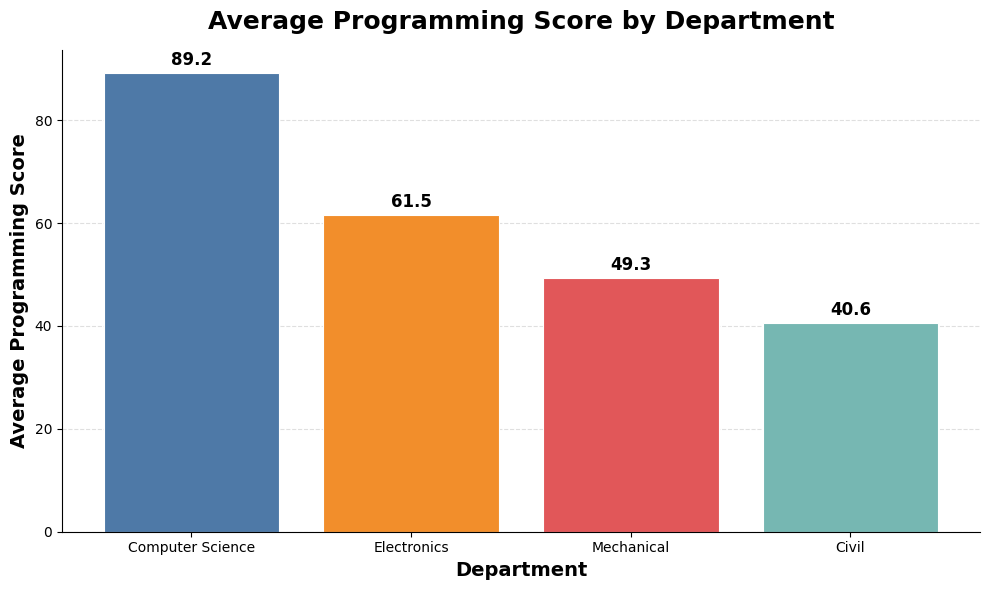

In [66]:
# ============================================================
# CELL 16: Chart 1 – Bar Chart: Average Programming Score by Department
# ============================================================

# Step 1: Get data using SQL
chart1_sql = """
    SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
    FROM students
    GROUP BY department
    ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, con)

# pd.read_sql_query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_programming'


# ============================================================
# Step 2: Define color palette
# ============================================================

# Same color palette as our PPT slides for consistency
bar_colors = [
    '#4E79A7',   # blue
    '#F28E2B',   # orange
    '#E15759',   # red
    '#76B7B2',   # teal
    '#59A14F',   # green
    '#EDC948',   # yellow
    '#B07AA1',   # purple
    '#FF9DA7'    # pink
]


# ============================================================
# Step 3: Create the bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# fig = the whole figure (canvas)
# ax  = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall


# ============================================================
# Step 4: Draw bars
# ============================================================

bars = ax.bar(
    chart1_data['department'],      # x-axis values (category labels)
    chart1_data['avg_programming'],        # y-axis values (heights of bars)
    color=bar_colors,               # colors for each bar
    edgecolor='white',              # white border around each bar
    linewidth=0.8                   # thickness of the border
)

# ax.bar() draws one bar per x-value, with height = y-value


# ============================================================
# Step 5: Add value labels on top of bars
# ============================================================

for bar in bars:

    # Loop through each bar object
    height = bar.get_height()

    # .get_height() returns the bar's height (= avg_programming value)

    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position: center of bar
        height + 0.8,                        # y position: just above bar top
        f'{height:.1f}',                     # text: height formatted to 1 decimal
        ha='center',                         # horizontal alignment
        va='bottom',                         # vertical alignment
        fontsize=12,
        fontweight='bold',
        color='black'
    )


# ============================================================
# Step 6: Add titles and labels
# ============================================================

ax.set_title(
    'Average Programming Score by Department',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Department',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Average Programming Score',
    fontsize=14,
    fontweight='bold'
)


# ============================================================
# Step 7: Customize grid and style
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax.set_axisbelow(True)

# Removes top and right borders for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# Step 8: Display chart
# ============================================================

plt.tight_layout()
plt.show()

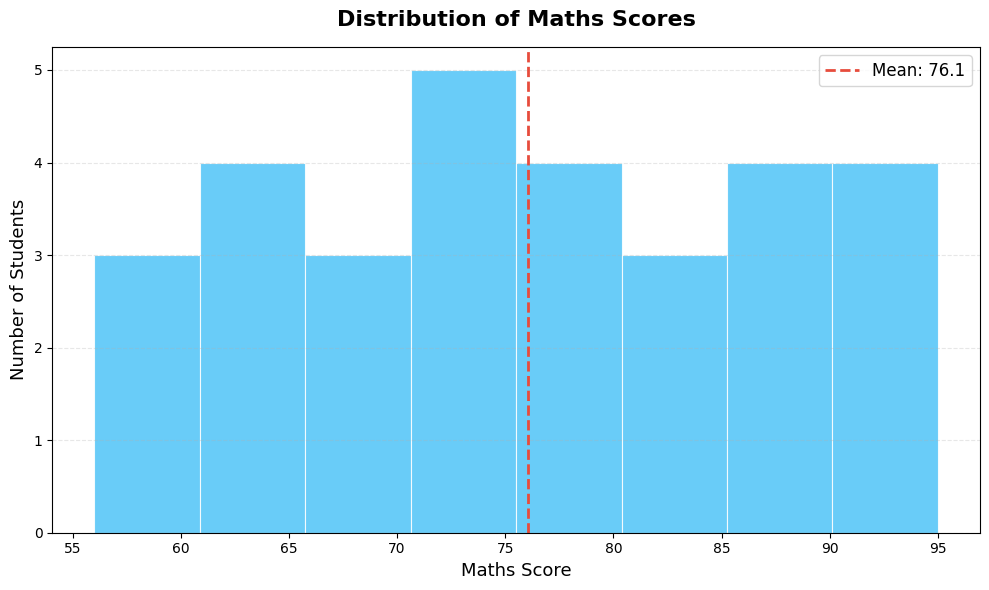

In [50]:
# ============================================================
# CELL 17: Chart 2 – Histogram: Distribution of Programming Scores
# ============================================================


# ============================================================
# Step 1: Get programming scores as a list
# ============================================================

prog_scores = df['math_score'].tolist()

# .tolist() converts a Pandas Series to a regular Python list
# Matplotlib's hist() works with both — tolist() is just explicit


# ============================================================
# Step 2: Create the histogram
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))


n, bins, patches = ax.hist(
    prog_scores,              # The data to visualize
    bins=8,                   # Divide score range into 8 equal intervals
    color='#4FC3F7',          # Bar fill color
    edgecolor='white',        # White border between bars
    linewidth=0.8,
    alpha=0.85                # Slight transparency
)

# ax.hist() returns three values:
#   n       = frequency count for each bin
#   bins    = the bin edges (breakpoints on x-axis)
#   patches = the bar objects (we can color them individually)


# ============================================================
# Step 3: Add a vertical line showing the mean score
# ============================================================

mean_score = sum(prog_scores) / len(prog_scores)

ax.axvline(
    x=mean_score,                 # x position of the vertical line
    color='#E74C3C',              # red color for visibility
    linestyle='--',               # dashed line style
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'   # label for the legend
)

# axvline = 'axis vertical line' — draws a vertical reference line


# ============================================================
# Step 4: Add chart title and axis labels
# ============================================================

ax.set_title(
    'Distribution of Maths Scores',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Maths Score',
    fontsize=13
)

ax.set_ylabel(
    'Number of Students',
    fontsize=13
)


# ============================================================
# Step 5: Add legend and grid
# ============================================================

ax.legend(fontsize=12)      # Shows the mean line label

ax.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)


# ============================================================
# Step 6: Display the chart
# ============================================================

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


# Sample dataset (replace with your own CSV)
df = pd.DataFrame({
    'Category': np.random.choice(['A', 'B', 'C', 'D'], 100),
    'Value': np.random.randint(10, 100, 100),
    'Score': np.random.randint(1, 10, 100)
})


df.head()

,Category,Value,Score
0,A,32,5
1,C,52,7
2,B,21,3
3,C,59,8
4,D,28,6


In [53]:
import plotly.express as px

category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

fig = px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category", yaxis_title="Count")

fig.show()

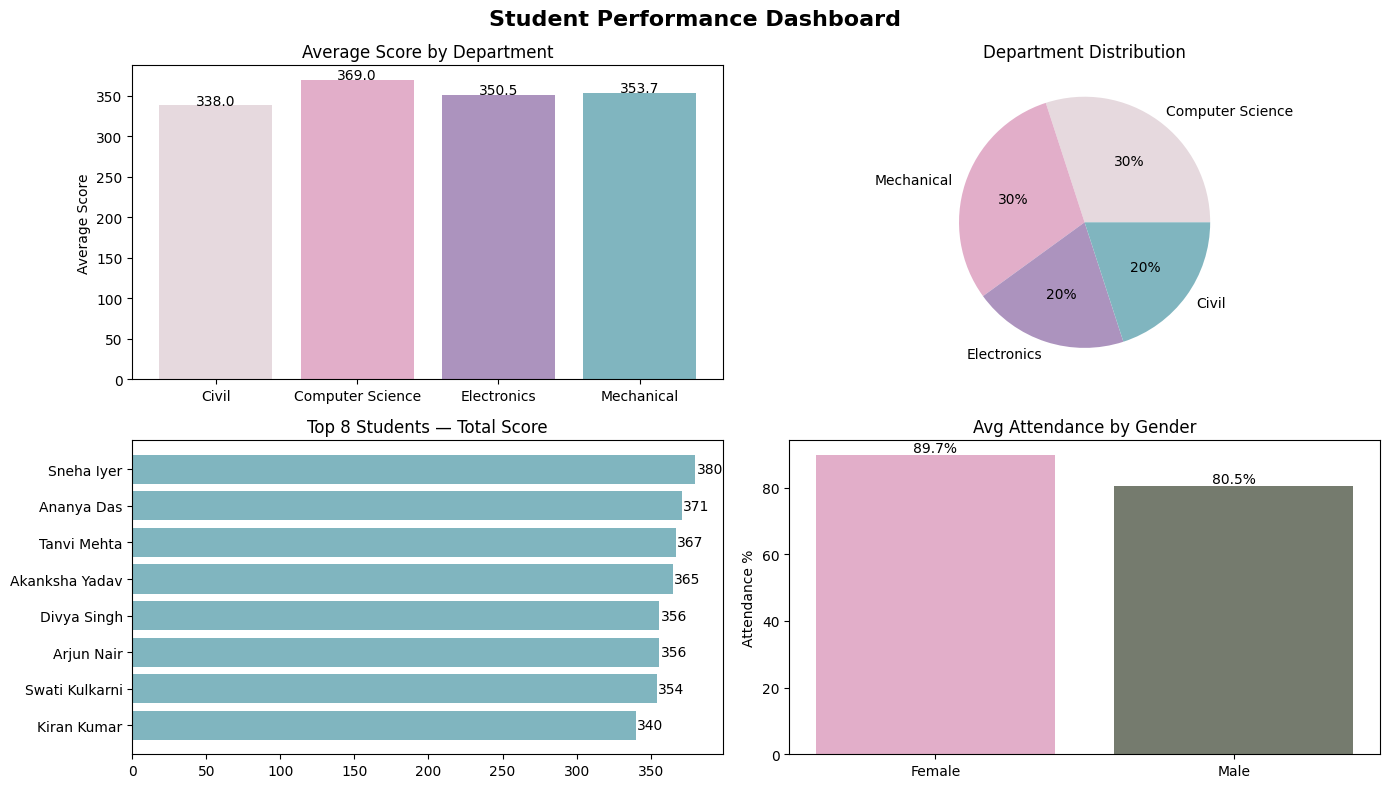

In [57]:
# ================================
# STUDENT ANALYSIS DASHBOARD
# ================================

# This dashboard visualizes:
# 1. Average Score by Department
# 2. Department Distribution
# 3. Top 8 Students by Total Score
# 4. Average Attendance by Gender

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Sample Dataset
# -------------------------------
data = {
    'Name': ['Ananya Das', 'Tanvi Mehta', 'Akanksha Yadav',
             'Arjun Nair', 'Divya Singh', 'Swati Kulkarni',
             'Amit Bose', 'Rahul Sharma', 'Sneha Iyer', 'Kiran Kumar'],

    'Department': ['Computer Science', 'Mechanical', 'Electronics',
                   'Computer Science', 'Civil', 'Mechanical',
                   'Electronics', 'Civil', 'Computer Science', 'Mechanical'],

    'Gender': ['Female', 'Female', 'Female',
               'Male', 'Female', 'Female',
               'Male', 'Male', 'Female', 'Male'],

    'Total_Score': [371, 367, 365, 356, 356, 354, 336, 320, 380, 340],

    'Attendance': [92, 89, 87, 78, 90, 86, 79, 82, 94, 83]
}

# Create DataFrame
df = pd.DataFrame(data)

# -------------------------------
# Create Dashboard Layout
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Student Performance Dashboard", fontsize=16, fontweight='bold')

# =====================================================
# 1. Average Score by Department (Bar Chart)
# =====================================================
avg_scores = df.groupby('Department')['Total_Score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)

axes[0, 0].set_title("Average Score by Department")
axes[0, 0].set_ylabel("Average Score")

# Add score labels
for i, value in enumerate(avg_scores.values):
    axes[0, 0].text(i, value + 1, f"{value:.1f}", ha='center')

# =====================================================
# 2. Department Distribution (Pie Chart)
# =====================================================
dept_counts = df['Department'].value_counts()

axes[0, 1].pie(
    dept_counts.values,
    labels=dept_counts.index,
    autopct='%1.0f%%'
)

axes[0, 1].set_title("Department Distribution")

# =====================================================
# 3. Top 8 Students - Total Score (Horizontal Bar Chart)
# =====================================================
top_students = df.sort_values(by='Total_Score', ascending=False).head(8)

axes[1, 0].barh(top_students['Name'], top_students['Total_Score'])

axes[1, 0].set_title("Top 8 Students — Total Score")

# Highest score at top
axes[1, 0].invert_yaxis()

# Add score labels
for i, value in enumerate(top_students['Total_Score']):
    axes[1, 0].text(value + 1, i, str(value), va='center')

# =====================================================
# 4. Average Attendance by Gender (Bar Chart)
# =====================================================
attendance_gender = df.groupby('Gender')['Attendance'].mean()

axes[1, 1].bar(attendance_gender.index, attendance_gender.values)

axes[1, 1].set_title("Avg Attendance by Gender")
axes[1, 1].set_ylabel("Attendance %")

# Add attendance labels
for i, value in enumerate(attendance_gender.values):
    axes[1, 1].text(i, value + 1, f"{value:.1f}%", ha='center')

# -------------------------------
# Adjust Layout
# -------------------------------
plt.tight_layout()

# Show Dashboard
plt.show()

Practice Questions
Question 1:

Write a SQL query to find the average programming score for female students only.

Question 2:

What is the difference between WHERE and HAVING? Write one example of each using the students table.

Question 3:

Write a SQL query to find all departments where the average attendance is above 85%.

Question 4:

What does pd.read_sql_query() return? What two arguments does it require?

Question 5:

Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

 avg_programming_score
                  70.2
          name  math_score
  Aarav Sharma          85
    Arjun Nair          92
   Divya Singh          88
    Ananya Das          95
    Suresh Rao          83
  Ritu Agarwal          87
Swati Kulkarni          90
   Tanvi Mehta          93
     Amit Bose          86
 Gaurav Shukla          84
Akanksha Yadav          91
      department  avg_attendance
Computer Science       90.692308
      department  avg_attendance
Computer Science       90.692308
    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female     

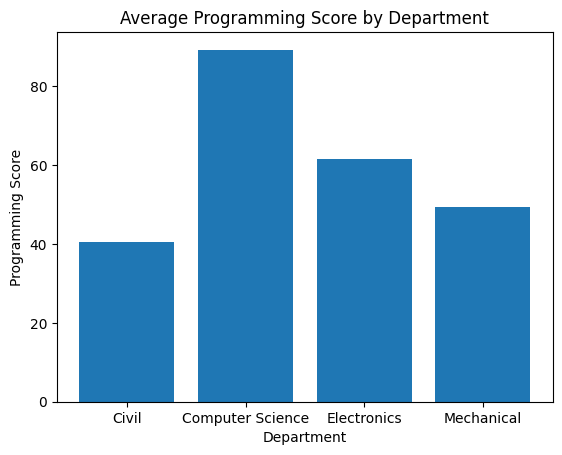

In [75]:
# Question 1
query_q1 = """
SELECT AVG(programming_score) AS avg_programming_score
FROM students
WHERE gender = 'Female';
"""
run_query(query_q1)


# Question 2

# WHERE → filters rows before GROUP BY
query_where = """
SELECT name, math_score
FROM students
WHERE math_score > 80;
"""
run_query(query_where)

# HAVING → filters groups after GROUP BY
query_having = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
run_query(query_having)


# Question 3
query_q3 = """
SELECT department, AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85;
"""
run_query(query_q3)


# Question 4

# pd.read_sql_query() returns a Pandas DataFrame

# Required arguments:
# 1. SQL query
# 2. Database connection object

df = pd.read_sql_query(
    "SELECT * FROM students",
    con
)

print(df)


# Question 5
avg_programming = df.groupby('department')['programming_score'].mean()

plt.bar(avg_programming.index, avg_programming.values)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Programming Score")

plt.show()

SAMPLE


In [76]:

run_query("SELECT * FROM students")


 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78              Delhi            2023
       1004    Sneha Reddy   20 Female       Mechanical         2          70             80             75                 48                     95          Hyderabad            2023
       1005     Arjun Nair   19   Male Computer Science         2          

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


**`Practice Question:`**

1. Find total number of students

2. Display all col names ansd data types using PRAGMA

3. Show the first 5 rows from the students table.

4. Display the student with math marks >80

5. Count the number of male and female students

6. Find the avg math score of all the students

In [77]:
# Question 1
query_q1 = "SELECT COUNT(*) AS total_students FROM students;"
run_query(query_q1)


# Question 2
cursor.execute("PRAGMA table_info(students)")
columns = cursor.fetchall()

for col in columns:
    print(col[1], "-", col[2])


# Question 3
query_q3 = "SELECT * FROM students LIMIT 5;"
run_query(query_q3)


# Question 4
query_q4 = """
SELECT name, math_score, department
FROM students
WHERE math_score > 80;
"""
run_query(query_q4)


# Question 5
query_q5 = """
SELECT gender, COUNT(*) AS total_students
FROM students
GROUP BY gender;
"""
run_query(query_q5)


# Question 6
query_q6 = """
SELECT AVG(math_score) AS avg_math_score
FROM students;
"""
run_query(query_q6)

 total_students
             30
student_id - INTEGER
name - TEXT
age - INTEGER
gender - TEXT
department - TEXT
semester - INTEGER
math_score - INTEGER
science_score - INTEGER
english_score - INTEGER
programming_score - INTEGER
attendance_percentage - INTEGER
city - TEXT
admission_year - INTEGER
 student_id         name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage      city  admission_year
       1001 Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92    Mumbai            2023
       1002  Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87 Ahmedabad            2023
       1003  Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78     Delhi            2023
       1

,avg_math_score
0,76.066667
